# Petri Dish Detection and Extraction

---

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [7]:
# Apply a mask to exclude high-noise areas before edge detection
def apply_noise_mask(image):
    """
    Applies a noise mask to the input grayscale image.
    This step removes high-intensity regions (e.g., reflections, bright blobs)
    to reduce noise before edge detection.

    Args:
        image (numpy.ndarray): Grayscale input image.

    Returns:
        numpy.ndarray: Masked image with high-intensity noise removed.
    """
    blurred = cv2.GaussianBlur(image, (11, 11), 0)  # Smooth the image to reduce noise.
    _, mask = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)  # Threshold bright areas.
    return cv2.bitwise_and(image, image, mask=cv2.bitwise_not(mask))  # Mask high-brightness regions.

# Normalize pixel intensity
def normalize_intensity(image):
    """
    Normalizes the pixel intensity of the grayscale image to enhance contrast.
    Combines histogram equalization and CLAHE (Contrast Limited Adaptive Histogram Equalization).

    Args:
        image (numpy.ndarray): Grayscale input image.

    Returns:
        numpy.ndarray: Image with normalized intensity.
    """
    equalized = cv2.equalizeHist(image)  # Global histogram equalization.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))  # CLAHE to enhance local contrast.
    return clahe.apply(equalized)

# Refine edges using morphological operations
def refine_edges(image):
    """
    Detects and refines edges in the input grayscale image using Canny edge detection
    followed by morphological operations to connect broken edges.

    Args:
        image (numpy.ndarray): Grayscale input image.

    Returns:
        numpy.ndarray: Binary edge map.
    """
    edges = cv2.Canny(image, 30, 150)  # Detect edges using Canny.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))  # Rectangular kernel for morphology.
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)  # Close gaps in edges.
    return edges

# Validate contour to ensure it's square-like and within size range
def validate_contour(contour, image_shape):
    """
    Validates a contour to ensure it represents a Petri dish.
    Checks for square-like aspect ratio, reasonable area, and minimum size.

    Args:
        contour (numpy.ndarray): Input contour.
        image_shape (tuple): Shape of the original image (height, width, channels).

    Returns:
        bool: True if the contour passes all validation checks, otherwise False.
    """
    x, y, w, h = cv2.boundingRect(contour)  # Bounding box around the contour.
    aspect_ratio = w / float(h)  # Check if the shape is approximately square.
    area = cv2.contourArea(contour)  # Calculate contour area.
    min_area = 100000  # Minimum acceptable area for a Petri dish.
    max_area = image_shape[0] * image_shape[1] * 0.8  # Maximum area (80% of the image).

    # Validate based on aspect ratio, area, and dimensions.
    if (
        0.9 <= aspect_ratio <= 1.1  # Square-like.
        and min_area <= area <= max_area
        and w > 100 and h > 100  # Minimum width and height.
    ):
        return True
    return False

# Adjust bounding box to ensure it is square
def enforce_square_bounding_box(x, y, w, h, image_shape):
    """
    Adjusts the bounding box to make it square and expand it slightly for edge inclusion.

    Args:
        x, y, w, h (int): Bounding box coordinates and dimensions.
        image_shape (tuple): Shape of the original image (height, width, channels).

    Returns:
        tuple: Adjusted bounding box (x, y, width, height).
    """
    size = max(w, h)  # Enforce square bounding box by taking the larger dimension.
    x = max(0, x - 5)  # Expand bounding box slightly on all sides.
    y = max(0, y - 5)
    x_end = min(x + size + 10, image_shape[1])  # Ensure bounding box stays within image bounds.
    y_end = min(y + size + 10, image_shape[0])
    return x, y, x_end - x, y_end - y  # Return square bounding box dimensions.

# Process a single image
def crop_petri_dish(image_path, dataset_type, output_dir):
    """
    Processes an image to detect and crop the Petri dish region.

    Args:
        image_path (str): Path to the input image.
        dataset_type (str): Type of dataset (e.g., 'Y2B_23' or 'Y2B_24') for specific preprocessing.
        output_dir (str): Directory to save the cropped images.

    Returns:
        None
    """
    image = cv2.imread(image_path)  # Load the image.
    if image is None:
        raise ValueError(f"Image not found: {image_path}")
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale.
    
    # Dataset-specific preprocessing steps.
    if dataset_type == "Y2B_23":
        gray_image = apply_noise_mask(gray_image)  # Apply noise mask.
        gray_image = normalize_intensity(gray_image)  # Normalize pixel intensity.
    elif dataset_type == "Y2B_24":
        gray_image = normalize_intensity(gray_image)  # Normalize pixel intensity.

    edges = refine_edges(gray_image)  # Detect and refine edges.
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # Find contours.
    valid_contours = [c for c in contours if validate_contour(c, image.shape)]  # Filter valid contours.
    if not valid_contours:
        raise ValueError("No valid contours found.")  # Raise an error if no valid contours exist.

    largest_contour = max(valid_contours, key=cv2.contourArea)  # Find the largest contour.
    x, y, w, h = cv2.boundingRect(largest_contour)  # Get the bounding box.
    x, y, w, h = enforce_square_bounding_box(x, y, w, h, image.shape)  # Adjust the bounding box.
    cropped_image = image[y : y + h, x : x + w]  # Crop the Petri dish.

    # Save the cropped image to the output directory.
    output_path = os.path.join(output_dir, os.path.basename(image_path))
    cv2.imwrite(output_path, cropped_image)
    print(f"Cropped image saved to: {output_path}")

# Example Usage
image_paths = [
    "val_Jason_234301_im2(Y2_24).png",
    "val_Jason_234301_im5(Y2_24).png",
    "033_43-14-ROOT1-2023-08-08_control_pH7_-Fe+B_col0_03-Fish Eye Corrected(Y2_23).png",
    "040_43-14-ROOT1-2023-08-08_pvdCherry_OD001_Col0_03-Fish Eye Corrected(Y2_23).png",
]
dataset_types = ["Y2B_24", "Y2B_24", "Y2B_23", "Y2B_23"]

Cropped image saved to: cropped_images\val_Jason_234301_im2(Y2_24).png
Cropped image saved to: cropped_images\val_Jason_234301_im5(Y2_24).png
Cropped image saved to: cropped_images\033_43-14-ROOT1-2023-08-08_control_pH7_-Fe+B_col0_03-Fish Eye Corrected(Y2_23).png
Cropped image saved to: cropped_images\040_43-14-ROOT1-2023-08-08_pvdCherry_OD001_Col0_03-Fish Eye Corrected(Y2_23).png


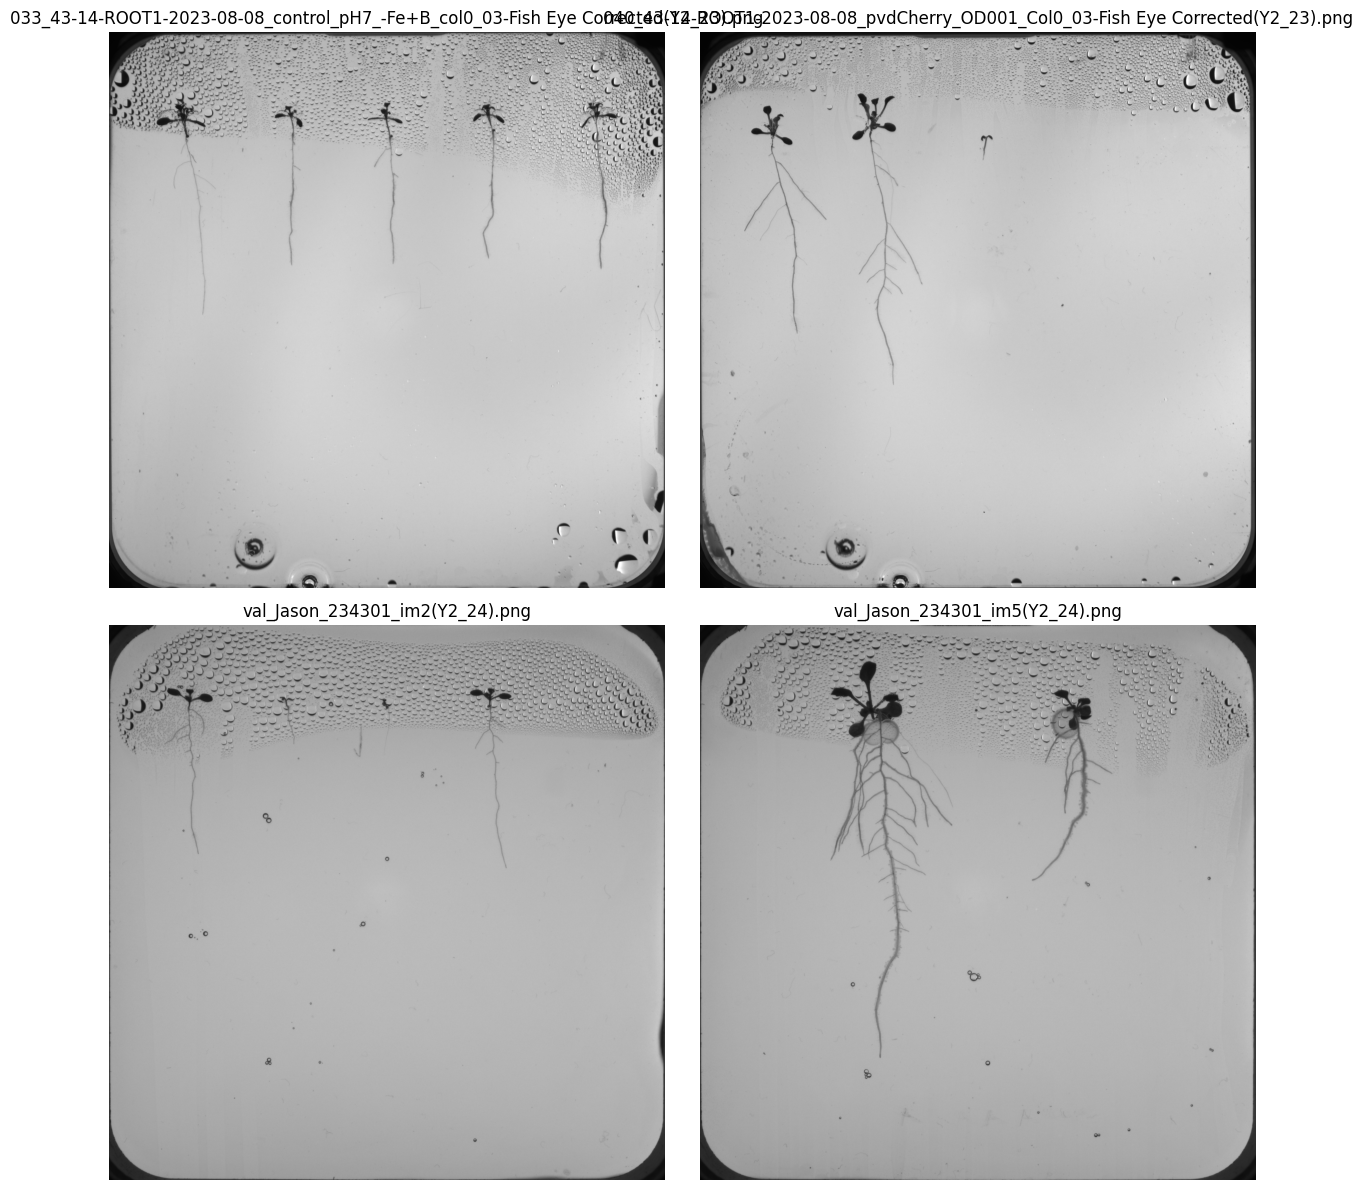

In [11]:
output_directory = "cropped_images"  # Directory to save cropped images.
os.makedirs(output_directory, exist_ok=True)

# Process each image and crop
for image_path, dataset_type in zip(image_paths, dataset_types):
    crop_petri_dish(image_path, dataset_type, output_directory)

# Display the cropped images
plt.figure(figsize=(12, 12))
for i, image_path in enumerate(os.listdir(output_directory)):
    image = cv2.imread(os.path.join(output_directory, image_path))
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(image_path)
    plt.axis("off")
plt.tight_layout()
plt.show()